This script tests fft

In [9]:
import numpy as np

def fft_conv(x1, x2):
    ne = len(x1)
    ne2 = 2*ne-1
    x1_t = np.fft.fft(x1, ne2)
    x2_t = np.fft.fft(x2, ne2)
    y_t = x1_t * x2_t
    y = np.fft.ifft(y_t)
    return y

def fft_rev_conv(x1, x2):
    ne = len(x1)
    ne2 = 2*ne-1
    x1_t = np.fft.fft(x1, ne2)
    x2_t = np.fft.fft(x2[::-1], ne2)
    y_t = x1_t * x2_t
    y = np.fft.ifft(y_t)
    return y

def fft_rev_conv_wrong(x1, x2):
    ne = len(x1)
    ne2 = 2*ne-1
    x1_t = np.fft.fft(x1, ne2)
    x2_t = np.fft.fft(x2, ne2)[::-1]
    y_t = x1_t * x2_t
    y = np.fft.ifft(y_t)
    return y

def rev_conv(x1, x2):
    # Note: This convolution is not symmetric rev_conv(x1, x2) != rev_conv(x2, x1)
    ne = len(x1)
    y = np.zeros(2*ne-1, dtype=complex)
    for i in range(ne):
        for j in range(ne):
            if j-i >= 0:
                y[i] += x1[j]*x2[j-i]
            else:
                continue
    return y

def reg_conv(x1, x2):
    ne = len(x1)
    y = np.zeros(2*ne-1)
    for i in range(ne):
        y[i:i+ne] += x1[i]*x2
    return y

def std_conv(x1, x2):
    ne = len(x1)
    y = np.zeros(2*ne-1)
    for i in range(ne):
        for j in range(ne):
            if i-j >= 0:
                y[i] += x1[j]*x2[i-j]
            else:
                continue
    return y

def conv(x1, x2):
    return np.convolve(x1, x2)

ne = 10
ne2 =2*ne-1
x = np.arange(ne) + 1j
x2 = np.arange(ne, ne*2)
# x = np.concatenate((np.zeros(ne), x, np.zeros(ne)))
print(fft_rev_conv(x, x2))
print(rev_conv(x2, x))
#print(fft_rev_conv_wrong(x, x))
#print(reg_conv(x2, x))
#print(std_conv(x, x2))
# np.allclose(fft_conv(x, x), reg_conv(x, x))

[-8.26473393e-14 +19.j  1.90000000e+01 +37.j  5.60000000e+01 +54.j
  1.10000000e+02 +70.j  1.80000000e+02 +85.j  2.65000000e+02 +99.j
  3.64000000e+02+112.j  4.76000000e+02+124.j  6.00000000e+02+135.j
  7.35000000e+02+145.j  6.90000000e+02+126.j  6.36000000e+02+108.j
  5.74000000e+02 +91.j  5.05000000e+02 +75.j  4.30000000e+02 +60.j
  3.50000000e+02 +46.j  2.66000000e+02 +33.j  1.79000000e+02 +21.j
  9.00000000e+01 +10.j]
[735.+145.j 600.+135.j 476.+124.j 364.+112.j 265. +99.j 180. +85.j
 110. +70.j  56. +54.j  19. +37.j   0. +19.j   0.  +0.j   0.  +0.j
   0.  +0.j   0.  +0.j   0.  +0.j   0.  +0.j   0.  +0.j   0.  +0.j
   0.  +0.j]


In [51]:
np.fft.fft(x[::-1], ne2)

array([ 45.        +45.j        , -47.18898298+10.52858832j,
        14.5004314 -14.75739284j, -12.05433155 +7.90585762j,
         7.59374529 -7.87320908j,  -7.23089533 +5.6815571j ,
         5.51229282 -5.83550986j,  -5.60472044 +4.76902568j,
         4.69921182 -5.1006617j ,  -5.03878239 +4.49377613j,
         4.49377613 -5.03878239j,  -5.1006617  +4.69921182j,
         4.76902568 -5.60472044j,  -5.83550986 +5.51229282j,
         5.6815571  -7.23089533j,  -7.87320908 +7.59374529j,
         7.90585762-12.05433155j, -14.75739284+14.5004314j ,
        10.52858832-47.18898298j])

In [49]:
x = x+1j*x

In [50]:
np.fft.fft(x, ne2)

array([ 36.        +36.j        , -11.61794077+39.27833544j,
       -18.24951421 +9.50647565j, -10.21576659 +5.36424051j,
       -10.54889333 +1.82835713j,  -7.52807133 +0.07740956j,
        -7.5770146  -1.09976836j,  -5.78304231 -2.38126293j,
        -5.69672123 -2.90182889j,  -4.3495207  -4.10547304j,
        -4.10547304 -4.3495207j ,  -2.90182889 -5.69672123j,
        -2.38126293 -5.78304231j,  -1.09976836 -7.5770146j ,
         0.07740956 -7.52807133j,   1.82835713-10.54889333j,
         5.36424051-10.21576659j,   9.50647565-18.24951421j,
        39.27833544-11.61794077j])

Is the Fourier transform always symmetric?

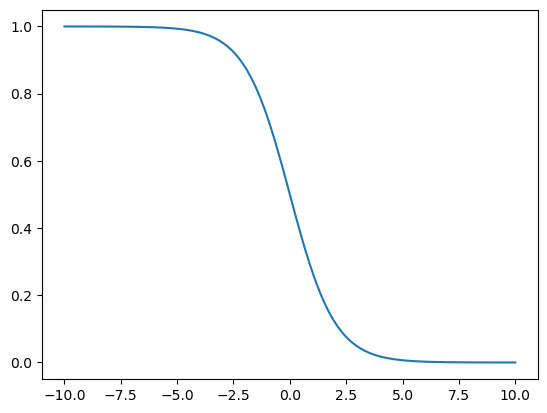

In [12]:
import matplotlib.pyplot as plt
x = np.linspace(-10,10, 100)
fermi = 1/(np.exp(x) + 1)
plt.plot(x, fermi)

In [10]:
import numpy as np
ne = 10
gl = 10*np.random.rand(ne) * 1j
energy = np.linspace(-10, 10, ne)
gg = np.exp(energy) * gl 
gl_t = np.fft.fft(gl, 2*ne-1)
gg_t = np.fft.fft(gg, 2*ne-1)
gl_t_rev = np.fft.fft(gl[::-1], 2*ne-1)
gg_t_rev = np.fft.fft(gg[::-1], 2*ne-1)

# gg_t = gg_t[1:]
# gl_t = gl_t[1:]
# gg_t_rev = gg_t_rev[1:]
# gl_t_rev = gl_t_rev[1:]

if not np.allclose(gg_t.conj(), -gg_t[::-1]):
    # print(gg_t.conj())
    # print(-gg_t[::-1])
    print("1:gg_t is not symmetric")

if not np.allclose(gg_t.conj(), -gg_t_rev):
    print("2:gg_t is not symmetric")

if not np.allclose(gl_t.conj(), -gl_t[::-1]):
    # print(gl_t.conj())
    # print(-gl_t[::-1])
    print("1:gl_t is not symmetric")

if not np.allclose(gl_t.conj(), -gl_t_rev):
    print("2:gl_t is not symmetric")


# pl_t = -1j * gl_t * gg_t[::-1] 
# pg_t = -1j * gg_t * gl_t[::-1]
pl_t = -1j * gl_t * gg_t_rev 
pg_t = -1j * gg_t * gl_t_rev

print(np.allclose(pl_t.conj(), -pl_t[::-1]))
print(np.allclose(pg_t.conj(), -pg_t[::-1]))
print(np.allclose(pl_t, pg_t[::-1]))
print(np.allclose(pl_t.conj(), -pg_t))

pl = np.fft.ifft(pl_t)
pg = np.fft.ifft(pg_t)

if not np.allclose(pl.conj(), -pl):
    print(pl.conj())
    print(-pl)
if not np.allclose(pg.conj(), -pg):
    print(pg.conj())
    print(-pg)
if not np.allclose(pl, pg[::-1]):
    print(pl)
    print(pg[::-1])
if not np.allclose(pl.conj(), -pg[::-1]):
    print(pl.conj())
    print(-pg[::-1])

1:gg_t is not symmetric
2:gg_t is not symmetric
1:gl_t is not symmetric
2:gl_t is not symmetric
False
False
False
False


In [11]:
print(pl)
print(pg)

[0.+1.96101046e+04j 0.+6.96825825e+04j 0.+1.04759667e+05j
 0.+1.41492167e+05j 0.+1.59603957e+05j 0.+8.68882607e+04j
 0.+2.78765102e+04j 0.+7.94481758e+04j 0.+1.44211786e+05j
 0.+8.22934029e+04j 0.+1.56279462e+04j 0.+9.33009858e+02j
 0.+3.54765892e+01j 0.+1.19830041e+01j 0.+2.38533517e+00j
 0.+2.29160261e-01j 0.+1.83866313e-02j 0.+1.32535874e-03j
 0.+4.04194549e-05j]
[0.+4.04194420e-05j 0.+1.32535875e-03j 0.+1.83866314e-02j
 0.+2.29160261e-01j 0.+2.38533517e+00j 0.+1.19830041e+01j
 0.+3.54765892e+01j 0.+9.33009858e+02j 0.+1.56279462e+04j
 0.+8.22934029e+04j 0.+1.44211786e+05j 0.+7.94481758e+04j
 0.+2.78765102e+04j 0.+8.68882607e+04j 0.+1.59603957e+05j
 0.+1.41492167e+05j 0.+1.04759667e+05j 0.+6.96825825e+04j
 0.+1.96101046e+04j]


In [12]:
import sys
sys.path.append('../../quatrex/utilities/')
from utilities.hilbert import HilbertTransform
en_hilbert = np.linspace(energy.min(), 2*energy.max()-energy.min(), 2*len(energy)-1, endpoint=True, dtype=float)
assert energy[1] - energy[0] == en_hilbert[1] - en_hilbert[0]
assert 2*energy.shape[0]-1 == en_hilbert.shape[0]
# hilbert_transform = HilbertTransform(en_hilbert, eta=1e-8, quatrex=True)
hilbert_transform = HilbertTransform(en_hilbert, eta=1e-18, quatrex=True)
hilbert_transform(1j*(pg-pl))

array([-1037068.26185212-3.08034802e+04j,
        -246717.82093987-2.18914285e+05j,
        -178409.10485387-3.29112143e+05j,
         -56380.95858759-4.44510034e+05j,
         172794.63687606-5.01403126e+05j,
         329214.24956407-2.72929876e+05j,
         236982.11681206-8.74651867e+04j,
         173875.7082623 -2.46662668e+05j,
         437958.98104346-4.03958046e+05j,
         662921.58492235+3.36449176e-28j,
         437958.98104346+4.03958046e+05j,
         173875.7082623 +2.46662668e+05j,
         236982.11681206+8.74651867e+04j,
         329214.24956407+2.72929876e+05j,
         172794.63687606+5.01403126e+05j,
         -56380.95858759+4.44510034e+05j,
        -178409.10485387+3.29112143e+05j,
        -246717.82093987+2.18914285e+05j,
       -1037068.26185212+3.08034802e+04j])

In [15]:
(pg-pl)/2

array([0. -9805.05228086j, 0.-34841.29058556j, 0.-52379.8243536j ,
       0.-70745.96914752j, 0.-79800.78599038j, 0.-43438.13885565j,
       0.-13920.51681242j, 0.-39257.58295292j, 0.-64291.91990038j,
       0.    +0.j        , 0.+64291.91990038j, 0.+39257.58295292j,
       0.+13920.51681242j, 0.+43438.13885565j, 0.+79800.78599038j,
       0.+70745.96914752j, 0.+52379.8243536j , 0.+34841.29058556j,
       0. +9805.05228086j])

In [85]:
print(-1j*rev_conv(gl, gg))
print(-1j*rev_conv(gg, gl))

[0.+9.03604673e+05j 0.+1.49784415e+05j 0.+1.38718011e+04j
 0.+7.68929432e+02j 0.+1.05907762e+02j 0.+3.86261403e+00j
 0.+8.82606451e-01j 0.+4.43704569e-02j 0.+7.01968175e-03j
 0.+1.75959285e-04j 0.-0.00000000e+00j 0.-0.00000000e+00j
 0.-0.00000000e+00j 0.-0.00000000e+00j 0.-0.00000000e+00j
 0.-0.00000000e+00j 0.-0.00000000e+00j 0.-0.00000000e+00j
 0.-0.00000000e+00j]
[0. +903604.67256775j 0.+1382182.77120513j 0.+1181219.34385299j
 0. +604203.21325223j 0. +767932.74401977j 0. +258449.41689273j
 0. +544954.43234832j 0. +252805.10623846j 0. +369069.54756433j
 0.  +85369.32078171j 0.      -0.j         0.      -0.j
 0.      -0.j         0.      -0.j         0.      -0.j
 0.      -0.j         0.      -0.j         0.      -0.j
 0.      -0.j        ]


In [10]:
x_t = np.fft.fft(x, 2*ne-1)
print(x_t)
print(x_t[::-1])

[ 45.        +45.j          10.52858832-47.18898298j
 -14.75739284+14.5004314j    7.90585762-12.05433155j
  -7.87320908 +7.59374529j   5.6815571  -7.23089533j
  -5.83550986 +5.51229282j   4.76902568 -5.60472044j
  -5.1006617  +4.69921182j   4.49377613 -5.03878239j
  -5.03878239 +4.49377613j   4.69921182 -5.1006617j
  -5.60472044 +4.76902568j   5.51229282 -5.83550986j
  -7.23089533 +5.6815571j    7.59374529 -7.87320908j
 -12.05433155 +7.90585762j  14.5004314 -14.75739284j
 -47.18898298+10.52858832j]
[-47.18898298+10.52858832j  14.5004314 -14.75739284j
 -12.05433155 +7.90585762j   7.59374529 -7.87320908j
  -7.23089533 +5.6815571j    5.51229282 -5.83550986j
  -5.60472044 +4.76902568j   4.69921182 -5.1006617j
  -5.03878239 +4.49377613j   4.49377613 -5.03878239j
  -5.1006617  +4.69921182j   4.76902568 -5.60472044j
  -5.83550986 +5.51229282j   5.6815571  -7.23089533j
  -7.87320908 +7.59374529j   7.90585762-12.05433155j
 -14.75739284+14.5004314j   10.52858832-47.18898298j
  45.        +45.j  